# Q7: How should current strategies be changed to achieve the set goals?

In this part of the analysis (Question 7), the goal is to find the main factors that have the biggest impact on CO₂ emissions at the country level. Understanding these factors is important for creating effective policies to reduce emissions and fight climate change.

To measure the importance of different variables, two machine learning models are used: 
1. **Random Forest**
2. **XGBoost**

The analysis is done separately for each country. This helps us better understand how emissions are different across countries and what factors influence them the most in each case.

In [15]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Loading the dataset

We use the OWID dataset, selecting the following columns:
`country`, `year`, `population`, `gdp`, `co2`, `primary_energy_consumption`, `energy_per_capita`, `energy_per_gdp`, `land_use_change_co2`, `methane`, `nitrous_oxide`

These variables are selected to focus on the main drivers of CO₂ emissions, while avoiding variables that are directly derived from CO₂ and could lead to misleading results.
- `population` and `gdp` represent demographic and economic activity, which strongly influence energy demand and emissions.
- `primary_energy_consumption`, `energy_per_capita`, and `energy_per_gdp `capture energy use and efficiency, which are key factors behind CO₂ emissions.
- `land_use_change_co2` reflects emissions from deforestation and land-use changes, which are not directly tied to fossil fuel combustion.
- `methane` and `nitrous_oxide` are important greenhouse gases that help describe broader emission patterns related to agriculture and industry.
- `year` and `country` provide temporal and spatial context for the analysis.

Variables directly related to CO₂ emissions (such as coal, oil, and gas CO₂) are excluded to avoid data leakage, since they are mathematically linked to the target variable. This allows the model to learn more meaningful and interpretable relationships between underlying drivers and CO₂ emissions.

In [16]:
dataset_url="https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(dataset_url)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

In [17]:
relevant_columns = [
    'country', 'iso_code', 'year', 'co2', 
    'population',
    'gdp',
    'primary_energy_consumption',
    'energy_per_capita',
    'energy_per_gdp',
    'methane',
    'nitrous_oxide',
    'land_use_change_co2'
]

goliaths = ["China", "United States", "Russia", "Japan", "Germany", "United Kingdom", "France", "Ukraine"]
goliaths_iso3 = ['CHN', 'USA', 'RUS', 'JPN', 'DEU', 'IND', 'GBR', 'SAU', 'IRN', 'FRA']

df_goliaths = df[df['iso_code'].isin(goliaths_iso3)][relevant_columns].copy()

In the previous analysis, we used data starting from 1970. Therefore, we will exclude all earlier values from the dataset.

In [18]:
df_goliaths = df_goliaths[df_goliaths['year'] >= 1970]

# Show first rows
df_goliaths.head()

,country,iso_code,year,co2,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp,methane,nitrous_oxide,land_use_change_co2
9879,China,CHN,1970,807.964,823308964.0,1.144004e+12,2361.698,2868.545,2.064,586.169,133.666,1336.049
9880,China,CHN,1971,909.210,844069870.0,1.216238e+12,2800.124,3317.408,2.302,605.290,137.753,882.614
9881,China,CHN,1972,968.636,863677810.0,1.233565e+12,3018.837,3495.327,2.447,620.731,144.494,1554.922
9882,China,CHN,1973,1008.269,882576945.0,1.334375e+12,3186.893,3610.895,2.388,627.290,151.361,1399.996
9883,China,CHN,1974,1028.063,900307580.0,1.367632e+12,3286.762,3650.710,2.403,633.566,151.560,1380.832


In [19]:
# Find if any country from goliaths_iso3 list is missing
df_iso3_codes = df_goliaths['iso_code'].unique()
missing = set(goliaths_iso3) - set(df_iso3_codes)
if not missing:
    print(f"SUCCESS: All {len(df_iso3_codes)} Goliaths are present in the dataset!")

SUCCESS: All 10 Goliaths are present in the dataset!


### Check for Missing Values

We inspect missing data to decide how to handle them. Target column co2 cannot have nulls. Other features can be filled or interpolated.

In [20]:
# Number of missing values per column
df_goliaths.isnull().sum()

country                        0
iso_code                       0
year                           0
co2                            0
population                     0
gdp                           20
primary_energy_consumption    15
energy_per_capita             15
energy_per_gdp                35
methane                        0
nitrous_oxide                  0
land_use_change_co2            0
dtype: int64

In [21]:
# Percentage of missing values
(df_goliaths.isnull().mean() * 100).round(2)

country                       0.00
iso_code                      0.00
year                          0.00
co2                           0.00
population                    0.00
gdp                           3.64
primary_energy_consumption    2.73
energy_per_capita             2.73
energy_per_gdp                6.36
methane                       0.00
nitrous_oxide                 0.00
land_use_change_co2           0.00
dtype: float64

There are very few missing values remaining. We will handle them using interpolation.

## Handle Missing Values

In [29]:
df_goliaths = df_goliaths.sort_values(by=['country', 'year'])

cols_to_interpolate = [
    'gdp', 'primary_energy_consumption', 'energy_per_capita', 'energy_per_gdp'
]

df_goliaths[cols_to_interpolate] = df_goliaths.groupby('country')[cols_to_interpolate] \
                                               .transform(lambda g: g.interpolate(method='linear', limit_direction='both'))

## Model Training with XGBoost

The next step is to train a machine learning model to understand which factors have the biggest impact on CO₂ emissions.

We use the XGBoost regression model, which works well with structured data and can capture complex relationships between variables.

For this analysis, we train the model on all available historical data for each country. We do not focus on predicting future values, so we do not need a separate test set.

After training, we extract feature importance scores from the model. These scores show which factors have the strongest influence on CO₂ emissions in each country, helping us understand the main drivers of emissions.

In [30]:
def feature_importance_by_country(df, features, target='co2'):
    results_importance = {}

    for country in df['country'].unique():
        df_country = df[df['country'] == country].sort_values('year')
        X = df_country[features]
        y = df_country[target]

        model = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                             reg_alpha=1, reg_lambda=1, random_state=42)
        model.fit(X, y)

        results_importance[country] = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

    importance_df = pd.DataFrame(results_importance).T
    return importance_df

In [31]:
features_final = [
    'population',
    'gdp',
    'primary_energy_consumption',
    'energy_per_capita',
    'energy_per_gdp',
    'methane',
    'nitrous_oxide',
    'land_use_change_co2'
]

importance_df = feature_importance_by_country(df_goliaths, features_final)

In [32]:
importance_table = importance_df.copy()
importance_table = importance_table[importance_table.mean().sort_values(ascending=False).index]
importance_table.head(10)

,population,gdp,primary_energy_consumption,nitrous_oxide,energy_per_capita,energy_per_gdp,methane,land_use_change_co2
China,0.914980,0.052558,0.007454,8.296550e-05,0.019844,0.000024,0.000848,0.004209
France,0.915971,0.001641,0.006425,8.812640e-03,0.023138,0.040619,0.001559,0.001834
Germany,0.099160,0.805383,0.004901,4.301898e-03,0.026635,0.034829,0.000227,0.024563
India,0.827704,0.171917,0.000000,5.072683e-07,0.000379,0.000000,0.000000,0.000000
Iran,0.938411,0.014056,0.008130,2.754295e-04,0.037548,0.000050,0.000450,0.001079
Japan,0.013497,0.002921,0.971262,8.769237e-04,0.006350,0.000565,0.001897,0.002632
Russia,0.072089,0.000557,0.038810,8.297265e-01,0.006748,0.008609,0.043225,0.000236
Saudi Arabia,0.954774,0.009724,0.007874,1.246698e-03,0.003282,0.004303,0.018022,0.000774
United Kingdom,0.197728,0.001284,0.002539,2.839555e-03,0.762042,0.009959,0.022665,0.000943
United States,0.025327,0.858385,0.036068,6.912785e-02,0.004330,0.005112,0.000435,0.001214


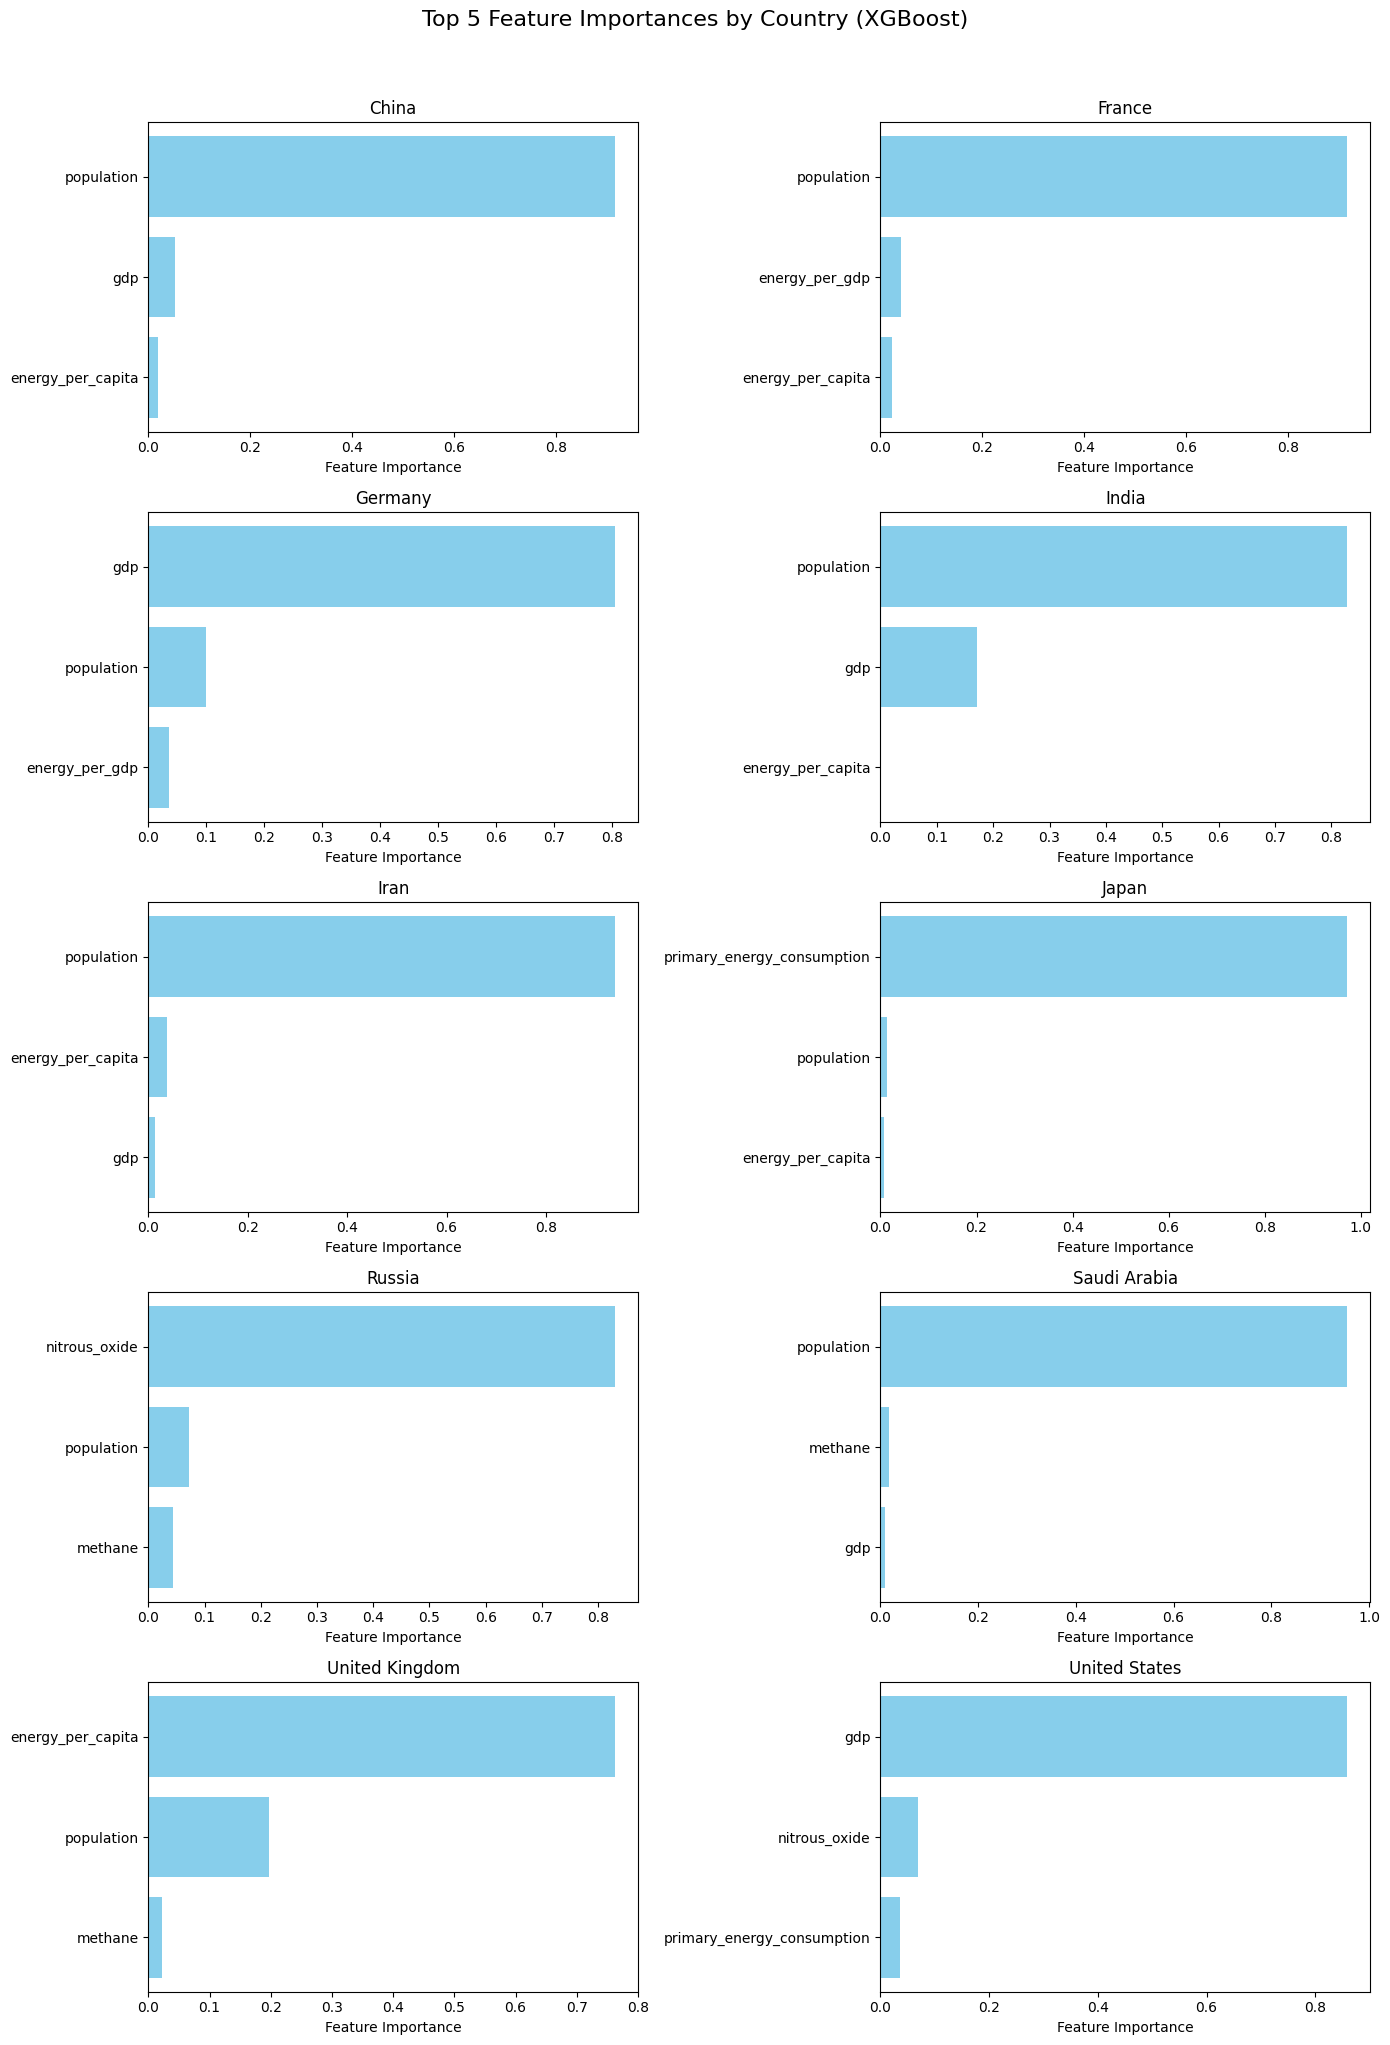

In [34]:
countries = importance_df.index.tolist()
n_countries = len(countries)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 20))
fig.suptitle("Top 5 Feature Importances by Country (XGBoost)", fontsize=16, y=1.02)
axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]
    # top three features
    top_features = importance_df.loc[country].sort_values(ascending=False).head(3)
    ax.barh(top_features.index[::-1], top_features.values[::-1], color='skyblue')
    ax.set_title(country, fontsize=12)
    ax.set_xlabel("Feature Importance")
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Conclusion

- **China** – `population` (91.5%), `gdp` (5.3%), `energy_per_capita` (2.0%) – the largest impact comes from `population`; focus on **energy efficiency and renewable energy in industry and transport**.  
- **France** – `population` (91.6%), `energy_per_capita` (2.3%), `nitrous_oxide` (0.9%) – `population` dominates; focus on **reducing agricultural emissions and increasing energy efficiency**.  
- **Germany** – `gdp` (80.5%), `energy_per_gdp` (3.5%), `land_use_change_co2` (2.5%) – `gdp` is key; focus on **industrial efficiency and green energy transition**.  
- **India** – `population` (82.8%), `gdp` (17.2%), `energy_per_capita` (0.0%) – `population` and `gdp` dominate; focus on **renewable energy and energy-efficient infrastructure**.  
- **Iran** – `population` (93.8%), `energy_per_capita` (3.8%), `primary_energy_consumption` (0.8%) – `population` is the largest factor; focus on **reducing fossil fuel use and modernizing industry**.  
- **Japan** – `primary_energy_consumption` (97.1%), `energy_per_capita` (0.6%), `methane` (0.2%) – `primary_energy_consumption` has the largest impact; focus on **reducing energy use and switching to renewables**.  
- **Russia** – `nitrous_oxide` (82.9%), `methane` (4.3%), `primary_energy_consumption` (3.9%) – `nitrous_oxide` and `methane` dominate; focus on **reducing industrial and agricultural emissions**.  
- **Saudi Arabia** – `population` (95.5%), `methane` (1.8%), `primary_energy_consumption` (0.8%) – `population` and `primary_energy_consumption` dominate; focus on **renewables and lowering energy consumption**.  
- **United Kingdom** – `energy_per_capita` (76.2%), `land_use_change_co2` (2.3%), `methane` (2.3%) – `energy_per_capita` is the main factor; focus on **reducing energy consumption and controlling agricultural emissions**.  
- **United States** – `gdp` (85.8%), `primary_energy_consumption` (3.6%), `land_use_change_co2` (0.1%) – `gdp` dominates; focus on **renewables, efficient transport, and industrial efficiency**.

## Model Training with Random Forest

In [39]:
def train_rf_by_country(df, features, target='co2'):
    countries = df['country'].unique()
    results = {}

    for country in countries:
        df_country = df[df['country'] == country].sort_values('year')
        y = df_country[target]
        X = df_country[features]
        
        model = RandomForestRegressor(
            n_estimators=200,
            max_depth=4,
            random_state=42
        )
        
        model.fit(X, y)
        results[country] = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

    return results

In [40]:
rf_results = train_rf_by_country(df_goliaths, features_final)

In [42]:
importance_table_rf = pd.DataFrame(rf_results).T
importance_table_rf = importance_table_rf[importance_table_rf.mean().sort_values(ascending=False).index]
importance_table_rf.head(10)

,primary_energy_consumption,nitrous_oxide,methane,gdp,population,energy_per_capita,energy_per_gdp,land_use_change_co2
China,0.134772,0.145170,0.167379,0.134055,0.135268,0.127909,0.013976,0.141472
France,0.019960,0.021264,0.293834,0.151659,0.212618,0.023598,0.165510,0.111557
Germany,0.014519,0.201775,0.246609,0.206599,0.062198,0.039185,0.208283,0.020832
India,0.179717,0.168014,0.174065,0.150269,0.152108,0.145072,0.025925,0.004832
Iran,0.218542,0.167969,0.001334,0.230417,0.177345,0.194694,0.006350,0.003349
Japan,0.592254,0.006408,0.011460,0.011725,0.024644,0.227437,0.007323,0.118750
Russia,0.049617,0.717852,0.096379,0.050169,0.054564,0.018724,0.008803,0.003891
Saudi Arabia,0.197509,0.159696,0.211712,0.169222,0.168426,0.008371,0.011030,0.074033
United Kingdom,0.078911,0.013109,0.134210,0.114340,0.210583,0.217704,0.223929,0.007215
United States,0.383839,0.111108,0.117280,0.082264,0.081623,0.078073,0.137931,0.007883


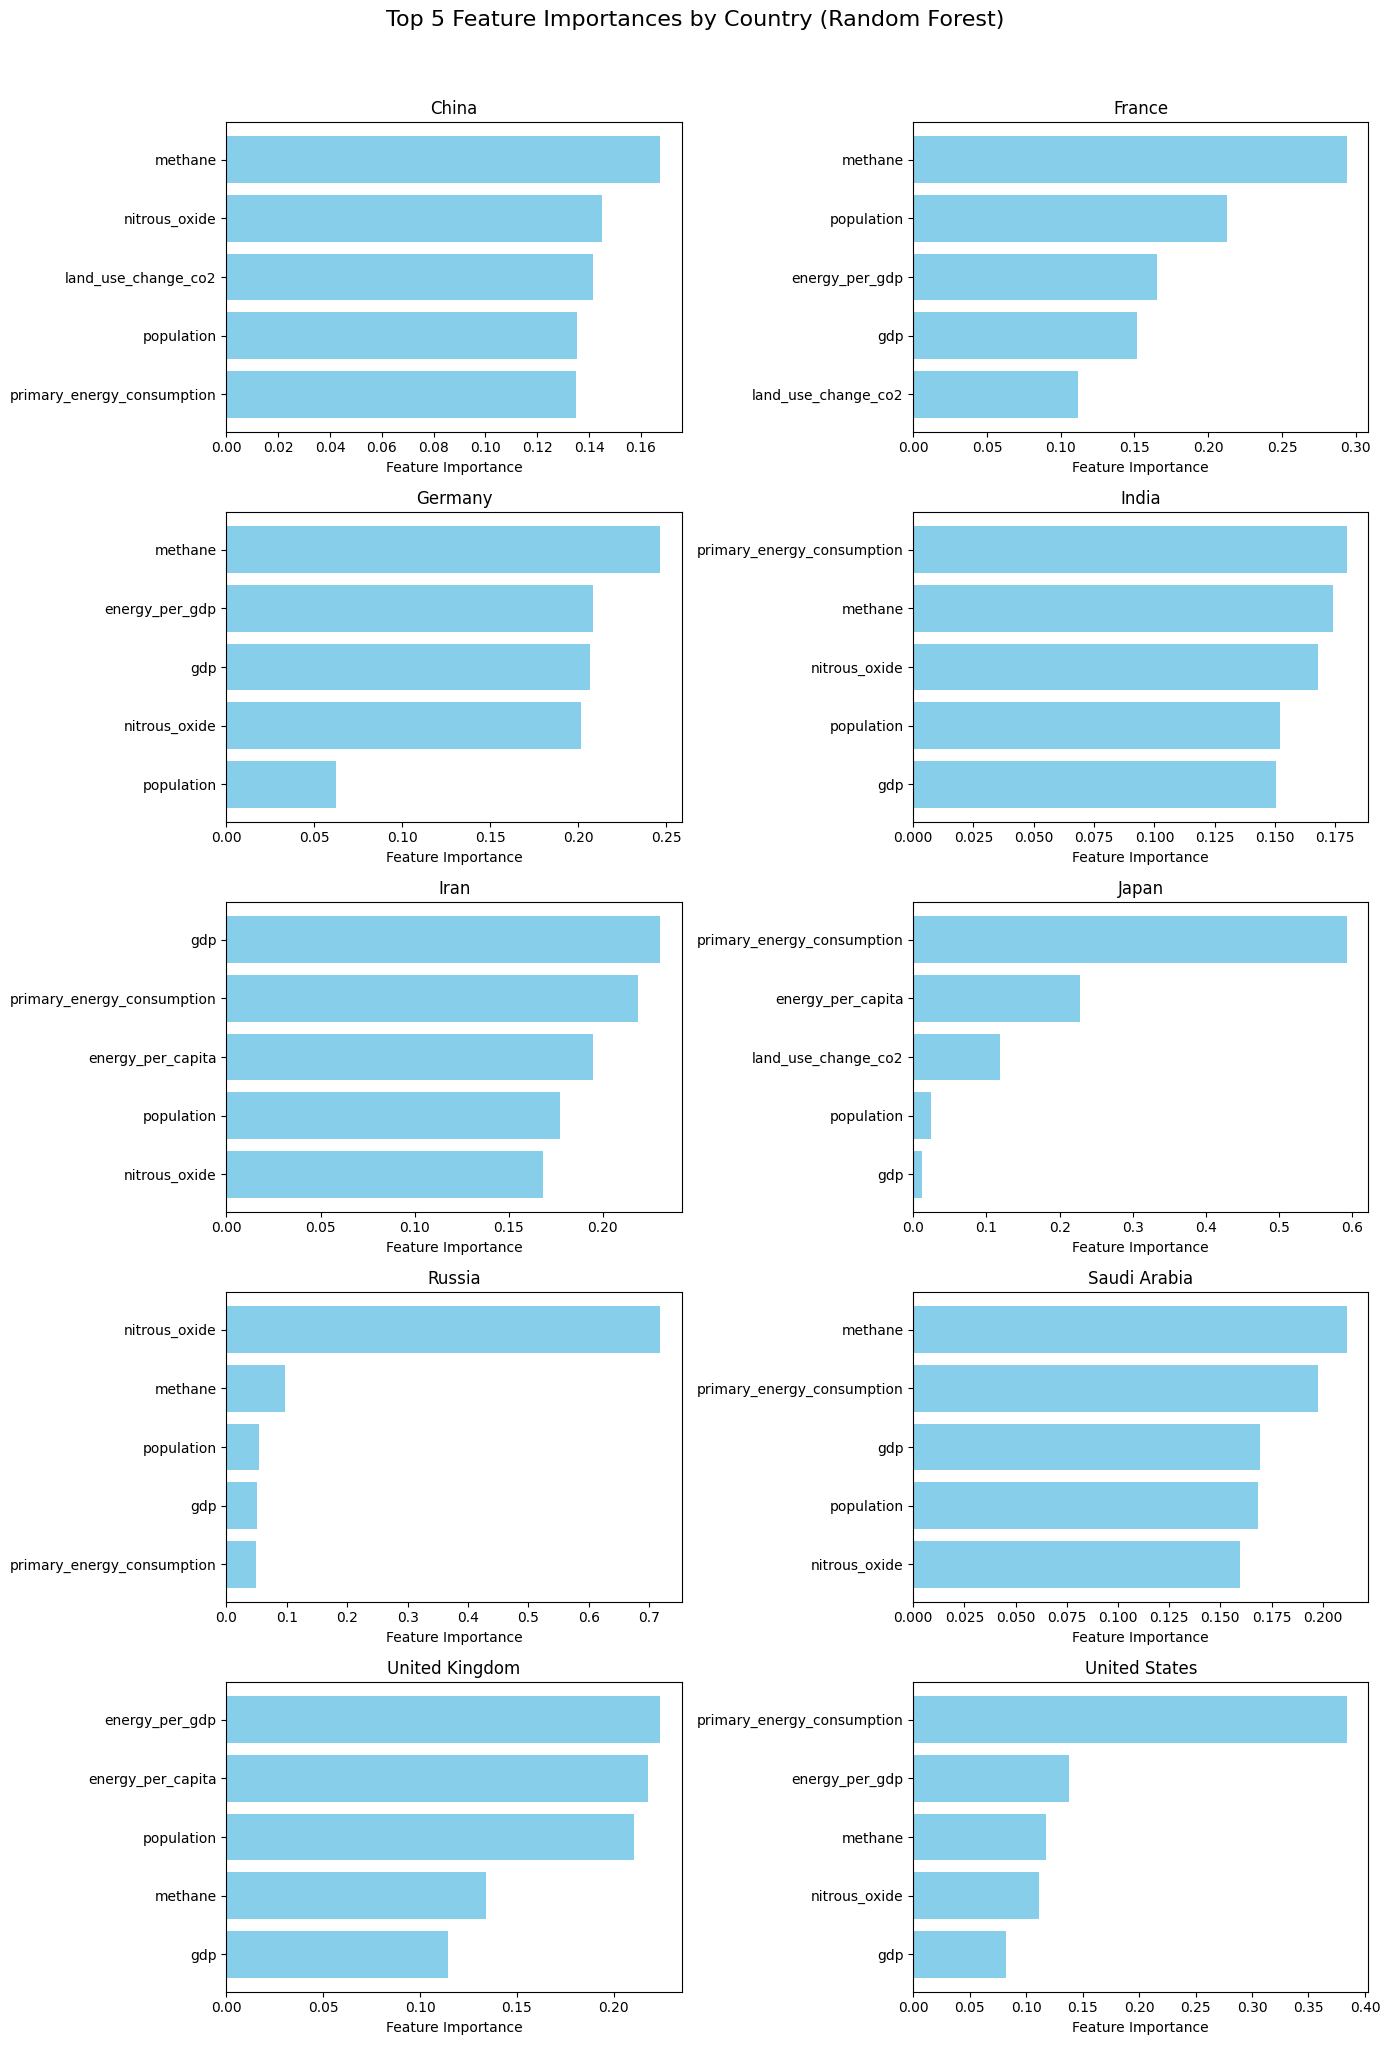

In [43]:
n_countries = len(countries)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 20))
fig.suptitle("Top 5 Feature Importances by Country (Random Forest)", fontsize=16, y=1.02)
axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]
    # top five features
    top_features = rf_results[country].head(5)
    ax.barh(top_features.index[::-1], top_features.values[::-1], color='skyblue')
    ax.set_title(country, fontsize=12)
    ax.set_xlabel("Feature Importance")
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Conclusion

- In most countries, energy (`primary_energy_consumption`) and agricultural gases (`methane`, `nitrous_oxide`) are the key factors.  
- `Population` and `GDP` are significant in countries with high growth and economic activity.  
- The focus of countries should be on **reducing energy consumption**, **transitioning to clean energy**, and **controlling industrial and agricultural gases**, rather than attempting to reduce GDP or population.

## Random Forest vs XGBoost

When comparing XGBoost and Random Forest for analyzing the importance of factors on CO₂ emissions by country, it is noticeable that XGBoost can produce unrealistic results in this context. The reason is that each country has a relatively small number of years of data, so the model easily overfits the entire historical series, giving very high R² values and absurdly distributed feature importances. This means that XGBoost "learns" almost all patterns in the data, and the numerical values of feature importance cannot always be directly interpreted.  

On the other hand, Random Forest distributes importance more evenly among features even with limited data, providing more realistic percentages and a more stable ranking of factors. Therefore, for our analysis, where the goal is solely to identify the most influential factors, Random Forest is the more reliable and practical model.